In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from transformers import AutoTokenizer

/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
metrics = pd.read_csv("training_metrics_3016.csv")

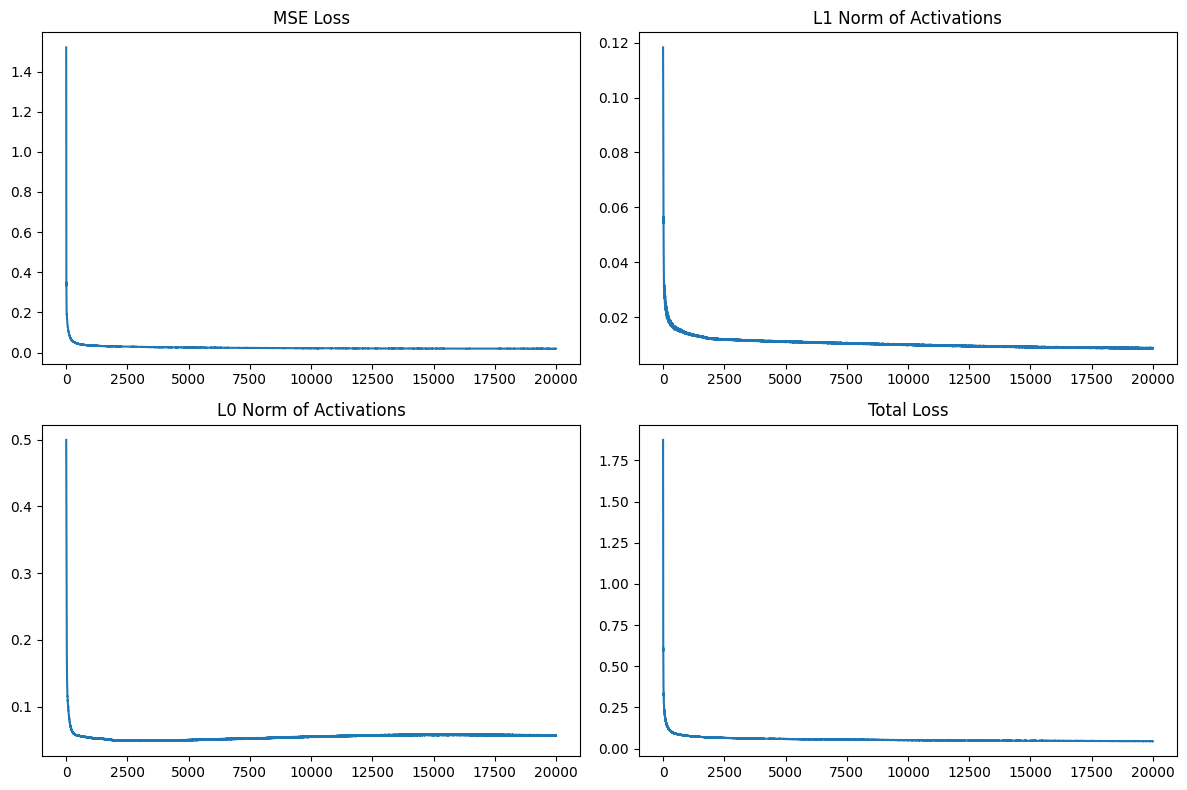

In [4]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [5]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load tokenizer only (no need for the full model)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")

# Load saved SAE
d, m = 512, 512 * 8
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load("sae_model.pt", map_location="cpu"))
sae.eval()

# Load activations and process through SAE encoder in batches
# Full encoder output would be ~88GB, so we process in chunks
NUM_TEXTS = 50000
ACTIVATIONS_PATH = f"activations/activations_{NUM_TEXTS}.pt"

activations = torch.load(ACTIVATIONS_PATH, map_location="cpu")
n_tokens = activations.shape[0]
BATCH_SIZE = 4096

# We only need top-k per feature, so we track running top-k instead of storing everything
K = 20  # track top-K activating tokens per feature
top_vals = torch.zeros(m, K)
top_idxs = torch.full((m, K), -1, dtype=torch.long)

with torch.no_grad():
    for start in tqdm.trange(0, n_tokens, BATCH_SIZE):
        batch = activations[start:start + BATCH_SIZE]
        feat_acts = sae.encoder(batch)  # (batch, 4096)

        for j in range(feat_acts.shape[1]):
            combined_vals = torch.cat([top_vals[j], feat_acts[:, j]])
            combined_idxs = torch.cat([top_idxs[j], torch.arange(start, start + feat_acts.shape[0])])
            best = combined_vals.topk(K)
            top_vals[j] = best.values
            top_idxs[j] = combined_idxs[best.indices]

del activations

# Re-tokenize the same texts to get token strings
# TransformerLens prepends a BOS token per text, so we must do the same
dataset = load_dataset("openwebtext", split="train", streaming=True)
BOS = tokenizer.bos_token_id

all_tokens = []
all_contexts = []
for i, example in enumerate(tqdm.tqdm(dataset, total=NUM_TEXTS)):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    token_ids = [BOS] + tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode(tid) for tid in token_ids]
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}, activations: {n_tokens}")
assert len(all_tokens) == n_tokens, f"Mismatch! tokens={len(all_tokens)} vs activations={n_tokens}"
print(f"Tracked top-{K} activations for {m} features")

100%|██████████| 50000/50000 [00:29<00:00, 1701.16it/s]

Total tokens: 5884867, activations: 5884867
Tracked top-20 activations for 4096 features


In [6]:
def inspect_feature(feature_idx, k=10):
    k = min(k, K)
    vals = top_vals[feature_idx, :k]
    idxs = top_idxs[feature_idx, :k]

    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(vals, idxs):
        idx = idx.item()
        if idx < 0:
            break
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(2)
print()
inspect_feature(100)

Feature 2 — top 10 activating tokens:

  2.194  token=         ' Feb'   context: Peter G. Aiken/Getty Images

The Cleveland Browns have endured another regime ch
  2.157  token=         ' Feb'   context: SEX, LOVE & HEALTH A-FAIRE

Monday, Feb. 10, 2014

Sac City Student Center

12 n
  2.148  token=         ' Feb'   context: Frank Victores/Associated Press

Cincinnati Bengals tight end Tyler Eifert suffe
  2.129  token=         ' Feb'   context: LGBT ATL turns on its heart lights. Whether you’re courting a sweetie, consideri
  2.129  token=         ' Feb'   context: Deanna Durante was in court during the "Black Madam" trial. Find out who the she
  2.091  token=         ' Feb'   context: NYPD auxiliary officers James Kiernan (left) and Jordan Martinez are accused of 
  2.056  token=         ' Feb'   context: Buy Photo Thomas Earl Crossley holds his sons old ASU baseball jersey as his wif
  2.055  token=         ' Feb'   context: The Winter Olympics is coming! In an inspired move, NBC ha

In [7]:
# Features where the best activation is 0 are dead
alive_mask = top_vals[:, 0] > 0
dead_count = (~alive_mask).sum().item()

# Sort alive features by their top activation (lowest = sparsest)
alive_idxs = torch.where(alive_mask)[0]
sorted_order = top_vals[alive_idxs, 0].argsort()
sparsest_idxs = alive_idxs[sorted_order]

print(f"Dead features: {dead_count} / {m}")
print()
for idx in sparsest_idxs[:10]:
    idx = idx.item()
    # Count non-zero entries in top-K as a proxy
    n_active = (top_vals[idx] > 0).sum().item()
    print(f"Feature {idx}: top activation = {top_vals[idx, 0]:.4f} ({n_active}/{K} top slots active)")
    inspect_feature(idx, k=5)
    print()

Dead features: 4 / 4096

Feature 1846: top activation = 0.0017 (1/20 top slots active)
Feature 1846 — top 5 activating tokens:

  0.002  token=          ' 10'   context: At 10 o’clock in the evening we arrived. The train stopped. We went onto the pla

Feature 3638: top activation = 0.0057 (1/20 top slots active)
Feature 3638 — top 5 activating tokens:

  0.006  token=        ' held'   context: BAGHDAD — As Iraq emerges from three years of war with the Islamic State group, 

Feature 691: top activation = 0.0068 (1/20 top slots active)
Feature 691 — top 5 activating tokens:

  0.007  token=        ' like'   context: Formula 1's omnipresent pursuit of safety usually remains under the radar and it

Feature 1233: top activation = 0.0082 (4/20 top slots active)
Feature 1233 — top 5 activating tokens:

  0.008  token=      ' series'   context: While popular documentary films like Fahrenheit 9/11 and No End In Sight explore
  0.005  token=            '0'   context: Cornucopia 0.3.3 - Legendari

In [9]:
# Rank features by strongest top activation
best_per_feature = top_vals[:, 0]
ranked = best_per_feature.argsort(descending=True)

for rank, idx in enumerate(ranked[:20]):
    idx = idx.item()
    print(f"=== Rank {rank+1}: Feature {idx} (top activation: {best_per_feature[idx]:.3f}) ===")
    inspect_feature(idx, k=5)
    print()

=== Rank 1: Feature 3289 (top activation: 168.386) ===
Feature 3289 — top 5 activating tokens:

  168.386  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  162.418  token=            '.'   context: Self-driving electric cars? Rad!! A Hyperloop train that can get you from New Yo
  162.109  token=            '.'   context: Fox News Channel pundits Greta Van Susteren and Erick Erickson have gone to war 
  161.757  token=            '.'   context: According to court documents, 29-year-old Markus Kaarma of Missoula, Mont. was i
  161.663  token=            '.'   context: Poison Ivy is a 1985 American made-for-television romantic comedy film starring 

=== Rank 2: Feature 3348 (top activation: 28.609) ===
Feature 3348 — top 5 activating tokens:

  28.609  token=            '.'   context: At MWC 2016, OPPO released its new SmartSensor image stabilization technology. A
  28.554  token=            '.'   context: A local police o

In [15]:
# Find the most "interpretable" features: ones where top-K tokens are consistent
# Score = fraction of top-K tokens that match the most common token
# Filter out single-char punctuation which dominates the max-activation ranking
from collections import Counter

BORING = {'.', "'", '-', '"', ',', '!', '?', ':', ';', '\n', ' ', ''}

scores = []
for feat_idx in range(m):
    idxs = top_idxs[feat_idx]
    valid = idxs[idxs >= 0]
    if len(valid) < 5:
        scores.append((feat_idx, 0.0, ""))
        continue
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    most_common_token, most_common_count = counts.most_common(1)[0]
    consistency = most_common_count / len(tokens)
    scores.append((feat_idx, consistency, most_common_token))

# Sort by consistency, filter out punctuation-only features
scores_filtered = [(idx, score, tok) for idx, score, tok in scores
                   if tok.strip() not in BORING and len(tok.strip()) > 0]
scores_filtered.sort(key=lambda x: -x[1])

print("Most consistent (interpretable) features:\n")
for feat_idx, consistency, top_token in scores_filtered[:30]:
    # if len(top_token) == 2:
    #     continue
    print(f"Feature {feat_idx}: {consistency:.0%} consistent, top token = {repr(top_token)}, max act = {top_vals[feat_idx, 0]:.3f}")
    inspect_feature(feat_idx, k=5)
    print()

Most consistent (interpretable) features:

Feature 1: 100% consistent, top token = ' ca', max act = 1.808
Feature 1 — top 5 activating tokens:

  1.808  token=          ' ca'   context: Star forward Eddie Betts will be entertaining Crows fans for years to come after
  1.757  token=          ' ca'   context: The family of Michael Brown appeared on NBC’s “Today” show, during which they we
  1.752  token=          ' ca'   context: Credit: Marvel Comics

Horror fiction icon R.L. Stine makes his comic book writi
  1.740  token=          ' ca'   context: Twenty years after helping his injured son across the finish line in Barcelona, 
  1.722  token=          ' ca'   context: TO HEAR Gov. Larry Hogan (R) tell it, Maryland is sinking fast, its people fleei

Feature 2: 100% consistent, top token = ' Feb', max act = 2.194
Feature 2 — top 5 activating tokens:

  2.194  token=         ' Feb'   context: Peter G. Aiken/Getty Images

The Cleveland Browns have endured another regime ch
  2.157  token=

In [17]:
inspect_feature(3440, k=5)
print()

Feature 3440 — top 5 activating tokens:

  7.957  token=      'Reuters'   context: March 13 (Reuters) - U.S. investigators suspect that Malaysia Airlines Flight 37
  7.946  token=      'Reuters'   context: MANILA (Reuters) - The Philippine government derided Catholic bishops on Sunday 
  7.946  token=      'Reuters'   context: MANILA (Reuters) - Philippine Vice President Jejomar Binay on Monday vowed to am
  7.924  token=      'Reuters'   context: DUBAI, April 4 (Reuters) - Iran has partially lifted a ban on women attending me
  7.902  token=      'Reuters'   context: NEW YORK, July 6 (Reuters) - A former Goldman Sachs (GS.N) computer programmer a

